Taavon Peoples QML Project

Data Encoding


weights are the output of training (fine tuning starts with weights from training)
-----

Try to reorder the features  to prove it works once we get a good result

We need to look at the data set again. There is not a line to be drawn for this use case. Maybe try looking at the original python script for tips. 

In [81]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [29]:
from qiskit_ibm_runtime import QiskitRuntimeService


QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh", #personal
     set_as_default = True
     )

QiskitRuntimeService.save_account(
     name="school",
     token="le-oO5tzHgBtECyLLKsPwvua8PGGWlshIAXyBxhN0BwS" #school
     )

In [ ]:
QiskitRuntimeService.saved_accounts()
testing = QiskitRuntimeService(name="school")

BEGIN METHODs needed for QNN 

In [82]:
def encode_grade(grade):
    if grade == 'A':
        return 1
    elif grade == 'B':
        return 2
    elif grade == 'C':
        return 3
    elif grade == 'D':
        return 4
    elif grade == 'F':
        return 5
    else:
        return 0
    
def convert_to_label(grade):
    #if grade in ['A', 'B']:
    if grade in ['A']:
        return 1
    else:
        return -1

In [83]:
from math import pi
import numpy as np

def process_dataset(dataset: pd.DataFrame, samples: int, random_seed: int) -> np.array:
    subset = dataset.sample(n=samples, random_state=random_seed)
    array_stacked = np.column_stack([subset[col].values for col in ['Grade', 'White','Black', 'Hispanic', 'Asian', 'Other', 'Total', 'NO2', 'PHOLC', 'PM25']])
    processed_data = list()

    # Normalize the data by dividing each value by the total number of samples in that row (column 6)
    # Normalize the totals by dividing by the max total in the dataset
    max = np.max(array_stacked[:, 6])
    for row in array_stacked:
        processed_data.append(np.array([
                            #(row[1] / row[6]) * 2 * pi, # % of White population
                            #(row[2] / row[6]) * 2 * pi, # % of Black population
                            #(row[3] / row[6]) * 2 * pi, # % of Hispanic population
                            #(row[4] / row[6]) * 2 * pi, # % of Asian population
                            #(row[5] / row[6]) * 2 * pi, # % of Other population
                            #(row[6] / max ) * 2 * pi,     # Normalized total
                            row[7],           # NO2 levels | Low is good
                            row[8],           # PHOLC levels
                            row[9],          # PM25 levels | high is bad
                            convert_to_label(row[0])]))  # Grade is encoded as a label, where A and B are 1 (good) and C, D, F are -1 (bad)          
    return np.array(processed_data)

In [84]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit.circuit.library import unitary_overlap

def create_encoding_circuits(dataset: pd.DataFrame, useZZ: bool) -> tuple [int, QuantumCircuit, QuantumCircuit]: 
    # Data points with labels removed, for inner product    
    train_data=[dataset[0][:-1], dataset[1][:-1]]

    # Encode the data into quantum states using the ZFeatureMap    
    if(useZZ):
        fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)
    else :
        fm = z_feature_map(feature_dimension=np.shape(train_data)[1])

    num_qubits = fm.num_qubits

    #Assign Params
    unitary1 = fm.assign_parameters(train_data[0])
    unitary2 = fm.assign_parameters(train_data[1])

    overlap_circ = unitary_overlap(unitary1, unitary2)
    overlap_circ.measure_all()
    return num_qubits, fm, overlap_circ

In [85]:
# Import the necessary packages
import array

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


''' For full dataset
  0 - # % of White population
  1 - # % of Black population
  2 - # % of Hispanic population
  3 - # % of Asian population
  4 - # % of Other population
  5 - # Normalized total 
  6 - # NO2 levels | Low is good
  7 - # PHOLC levels 
  8 - # PM25 levels | high is bad
'''
def create_ansatz_circuit(qubits: int, cnot_list: array) -> QuantumCircuit:
    # Initialize the circuit using the same number of qubits as the image has pixels
    qnn_circuit = QuantumCircuit(qubits)

    # We choose to have two variational parameters for each qubit.
    params = ParameterVector("θ", length=2 * qubits)   

    # A first variational layer:
    for i in range(qubits):
        qnn_circuit.ry(params[i], i)

    # Ansatz Designs will go here 
    # These should include ALL QUBITS
    # Here is a list of qubit pairs between which we want CNOT gates. 
    # Change this to include ALL of the demographic group qubits    
    for i in range(len(cnot_list)):
        qnn_circuit.cx(cnot_list[i][0], cnot_list[i][1])

    # The second variational layer:
    for i in range(qubits):
        qnn_circuit.rx(params[qubits + i], i)

    return qnn_circuit

In [86]:
import matplotlib.pyplot as plt

# Try pass manager several times, since heuristics can return various transpilations on large circuits, and we want the shallowest.
def find_min_transpiled_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    transpiled_qcs = []
    transpiled_depths = []
    transpiled_2q_depths = []
    for i in range(1, 10):
        circuit_ibm = pm.run(circuit)
        transpiled_qcs.append(circuit_ibm)
        transpiled_depths.append(circuit_ibm.decompose().depth())
        transpiled_2q_depths.append(
            circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)
        )
    # print(i)
    minpos = transpiled_2q_depths.index(min(transpiled_2q_depths))
    print(transpiled_depths)
    print(transpiled_2q_depths)

    # Use the shallowest
    return transpiled_qcs[minpos]

def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()

In [87]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")
    

def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    global objective_func_vals, circuit, input_params, estimator, observable
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

END METHODs needed for QNN

Step 1 Data Encoding
Map inputs to quantum circuit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()

# Baltimore statistics
baltimore_dataset = dataset[dataset['City'] == 'Baltimore, MD']

# Use sampling to get a random subset of 1000 rows, to avoid any bias in the data
from math import pi

sample_size = 5000
train_size = int(.8 * sample_size)
test_size = int(.2 * sample_size)

processed_data = process_dataset(dataset=baltimore_dataset, samples=sample_size, random_seed=42)                                      

print(processed_data) 

# Create the data sets from the processed data
# Training with more data
X_train = processed_data[0:train_size, :-1]
# The last column of the dataset contains the labels, so we take that for training labels
train_labels = processed_data[0:train_size, -1]

# Prepare testing data
X_test = processed_data[train_size : train_size + test_size, :-1]
test_labels = processed_data[train_size : train_size + test_size, -1]

num_samples = np.shape(X_train)[0]

[[10.4298      1.         11.6495     -1.        ]
 [15.3623      0.98758611 11.4141     -1.        ]
 [14.083       1.         10.2635     -1.        ]
 ...
 [14.496       1.         10.9273     -1.        ]
 [20.0246      1.         10.7818     -1.        ]
 [12.6944      1.         10.7624     -1.        ]]


circuit depth =  17


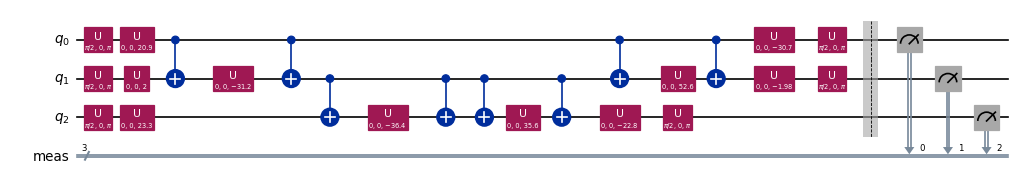

In [89]:
# Execute Data Encoding 
num_qubits, fm, overlap_circ = create_encoding_circuits(processed_data, True)
print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Create Ansatz to show data relationships. 

Think about how the values are related

6
2+ qubit depth: 4


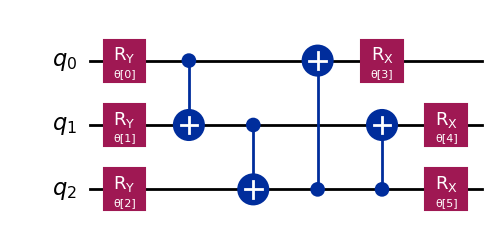

In [90]:
# Import the necessary packages
from qiskit import QuantumCircuit

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
# Change this to include ALL of the demographic group qubits 
#qnn_cnot_list = [[0,2],[0,1],[1,3],[3,2],[2,1],[3,0]]
qnn_cnot_list = [[0,1],[1,2],[2,0],[2,1]]
#qnn_cnot_list = [[6, 0], [8, 1], [8, 2]]

ansatz = create_ansatz_circuit(qubits=num_qubits, cnot_list=qnn_cnot_list)
# Check the circuit depth, and the two-qubit gate depth
print(ansatz.decompose().depth())
print(
    f"2+ qubit depth: {ansatz.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
ansatz.draw("mpl")

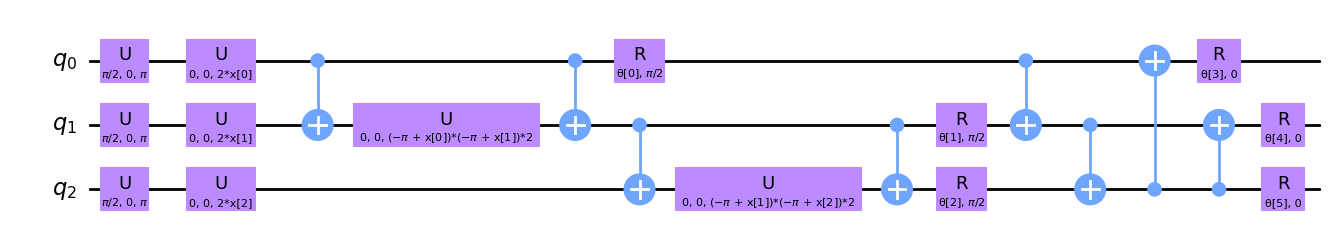

In [91]:
# QNN ansatz


# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(fm, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

Step 2
Optimize the circuit for execution

In [92]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend


service = QiskitRuntimeService()
# Using secondary QRS
#service = QiskitRuntimeService(name="school")
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-05-26 13:39:21,278: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open, pay-as-you-go), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-26 13:39:24,208: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-26 13:39:25,282: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-05-26 13:39:28,096: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


Transpilation STEPS (Compiling gates into native gates)

In [31]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target_backend = backend.target

pm = generate_preset_pass_manager(target=target_backend, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target_backend),
        ConstrainedReschedule(
            acquire_alignment=target_backend.acquire_alignment,
            pulse_alignment=target_backend.pulse_alignment,
            target=target_backend,
        ),
        PadDynamicalDecoupling(
            target=target_backend,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target_backend.pulse_alignment,
        ),
    ]
)

In [93]:
from qiskit.quantum_info import SparsePauliOp

circuit_ibm = find_min_transpiled_circuit(circuit=full_circuit)

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])
observable_ibm = observable.apply_layout(circuit_ibm.layout)

print(circuit_ibm.decompose().depth())
print(
    f"2+ qubit depth: {circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

overlap_ibm = pm.run(overlap_circ)

[89, 89, 89, 89, 89, 89, 89, 89, 89]
[9, 9, 9, 9, 9, 9, 9, 9, 9]
89
2+ qubit depth: 9


Add a section to draw the circuit after transpilation

In [ ]:
# Display the transpiled circuit
circuit_ibm.decompose().draw("mpl", style="clifford", fold=-1)

Step 3: Execute the circuit

SIMULATOR 

In [94]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

#num_shots = 1000
num_shots = sample_size

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [95]:
from scipy.optimize import minimize
from qiskit.primitives import StatevectorEstimator as Estimator

def execute_training_with_estimator(batch_size: int, epochs: int, samples: int, qc: QuantumCircuit): 
    global estimator, objective_func_vals, target, iter, input_params, circuit, X_train, train_labels
    estimator = Estimator()
    circuit = qc

    objective_func_vals = []
    iter = 0

    # Random initial weights for the ansatz
    np.random.seed(42)

    # This should not be random, changes this
    weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi  
    '''
        # % of White population
        # % of Black population
        # % of Hispanic population
        # % of Asian population
        # % of Other population
        # Normalized total 
        # NO2 levels | Low is good
        # PHOLC levels
        # PM25 levels | high is bad
    '''
    for epoch in range(epochs):
        for i in range((samples - 1) // batch_size + 1):
            print(f"Epoch: {epoch}, batch: {i}")
            print(weight_params)
            start_i = i * batch_size
            end_i = start_i + batch_size
            train_data_batch = np.array(X_train[start_i:end_i])
            train_labels_batch = np.array(train_labels[start_i:end_i])
            input_params = train_data_batch
            target = train_labels_batch
            iter = 0
            res = minimize(
                # Look into changing this method
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
            )
            weight_params = res["x"]

    return weight_params

In [ ]:
'''
SIMULATOR
'''
weight_params = execute_training_with_estimator(batch_size=150, epochs=5, samples=len(X_train), qc=full_circuit)


Epoch: 0, batch: 0
[2.35330497 5.97351416 4.59925358 3.76148219 0.98029403 0.98014248]
Iter: 0, loss: 1.08128038661827
Iter: 50, loss: 0.9784345433256344
Epoch: 0, batch: 1
[4.93476541 6.64554882 5.94457607 3.51284794 2.05433255 0.97997946]
Iter: 0, loss: 1.0389200670012597
Iter: 50, loss: 0.9578122919973789
Epoch: 0, batch: 2
[6.10054793 5.72439825 5.94537372 3.83928077 2.80828501 1.50515278]
Iter: 0, loss: 1.0259591613652939
Iter: 50, loss: 0.9357228411441569
Epoch: 0, batch: 3
[3.75444587 6.95990267 5.96254321 4.20841896 2.72032748 1.78257748]
Iter: 0, loss: 1.0704011702085021
Iter: 50, loss: 0.9482921154278955
Epoch: 0, batch: 4
[4.90028569 8.55053635 7.86113423 5.13281514 2.65028348 3.12216414]
Iter: 0, loss: 1.0045093064927935
Iter: 50, loss: 0.8703693237125568
Epoch: 0, batch: 5
[7.17092939 9.28272177 6.92772922 5.78490845 2.03386037 2.48261566]
Iter: 0, loss: 1.0657479352705783
Iter: 50, loss: 0.9532376824519307
Epoch: 0, batch: 6
[8.52100729 9.31299764 7.65410555 6.42040923 1.

REAL QUANTUM BACKEND REQUIRED 
The cell below is  for real QC execution.

In [92]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 2000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the  circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [ ]:
from scipy.optimize import minimize
from qiskit_ibm_runtime import EstimatorV2 as Estimator, Batch

'''
REAL QUANTUM COMPUTER | Each batch takes ~3 min. DO NOT RUN ON FREE ACCOUNT
'''
batch_size = 100
num_epochs = 1
num_samples = len(X_train)

# Globals
# Values for real quantum machine
# Use ibm circuit for real test
circuit = circuit_ibm
observable = observable_ibm

objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)

# This should not be random, changes this
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi
#weight_params = np.full(len(ansatz.parameters), 0.5) * 2 * np.pi
'''
    # % of White population
    # % of Black population
    # % of Hispanic population
    # % of Asian population
    # % of Other population
    # Normalized total 
    # NO2 levels | Low is good
    # PHOLC levels
    # PM25 levels | high is bad
'''

print(weight_params)
with Batch(backend=backend) as batch:
    estimator = Estimator(
        mode=batch, options={"resilience_level": 1}
    )
    for epoch in range(num_epochs):
        for i in range((num_samples - 1) // batch_size + 1):
            print(f"Epoch: {epoch}, batch: {i}")
            start_i = i * batch_size
            end_i = start_i + batch_size
            train_data_batch = np.array(X_train[start_i:end_i])
            train_labels_batch = np.array(train_labels[start_i:end_i])
            input_params = train_data_batch
            target = train_labels_batch
            iter = 0
            res = minimize(
                mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
            )
            weight_params = res["x"]
batch.close()



DATA VISUALIZATION STEPS

This Methods are just helpers for Kernel tests. All optional 

In [96]:
counts.get(0, 0.0) / num_shots

0.0002

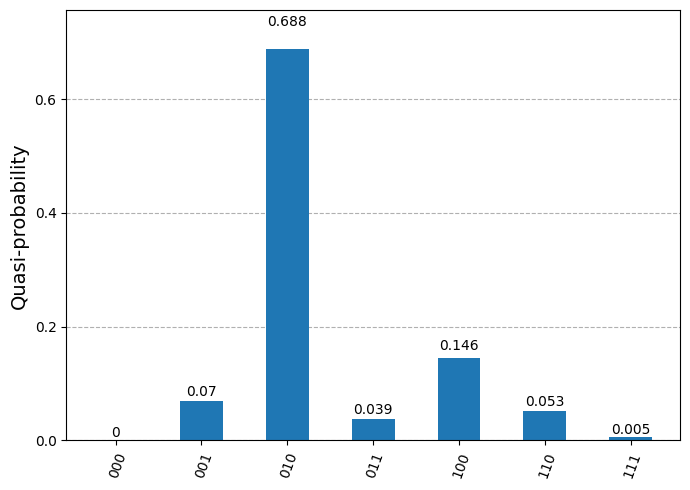

In [97]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


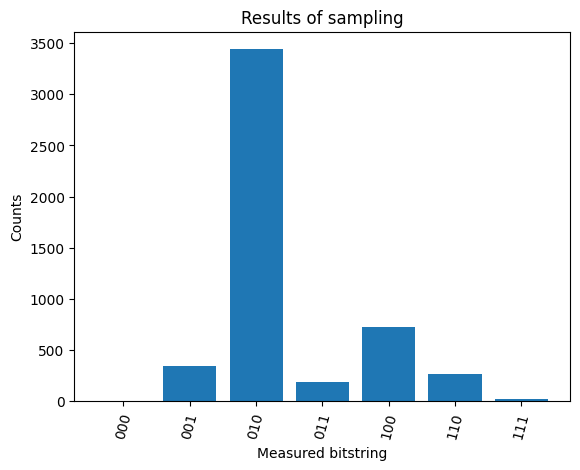

In [98]:
visualize_counts(counts, overlap_circ.num_qubits)

END of KERNEL VALIDATION METHODS

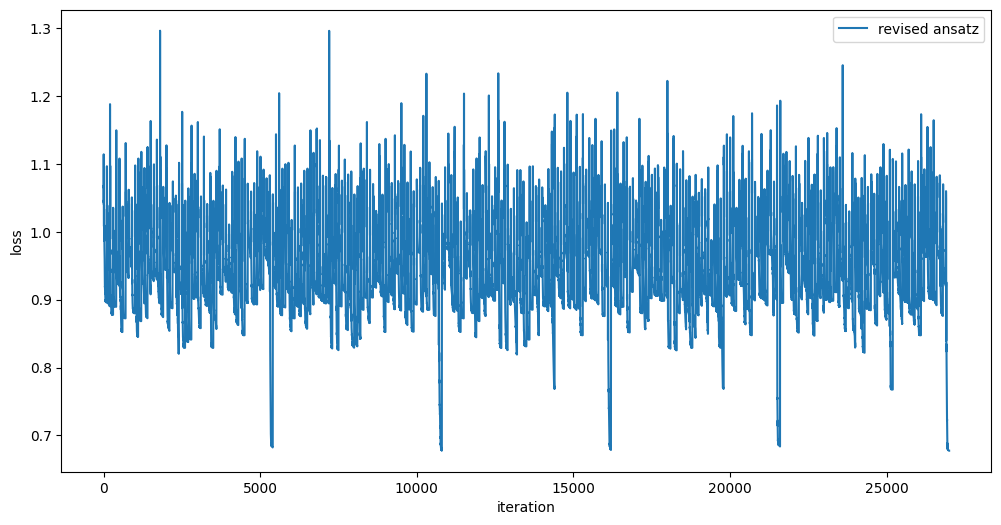

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals, label="revised ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
#from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

#estimator = Estimator()
#estimator = Estimator(backend=backend)

# Saved weights from previous training
#weight_params = [7.93003622, 4.8410845,  6.48850167, 2.47624698, 6.7189891,  0.91598247, 3.72400573, 5.02482112]
#weight_params = np.full(len(ansatz.parameters), 0.5) * 2 * np.pi

#[ 72.06960616  81.95897549  50.12440516 106.18568048  32.02334152 31.1162085    7.71122007  11.90835599]

pred_test = forward(circuit, np.array(X_test), weight_params, estimator, observable)

pred_test_labels = copy.deepcopy(pred_test)
pred_test_labels[pred_test_labels >= 0] = 1
pred_test_labels[pred_test_labels < 0] = -1
print(pred_test_labels)
print(test_labels)

accuracy = accuracy_score(test_labels, pred_test_labels)

print(f"Train accuracy: {accuracy * 100}%")

[ 1. -1.  1. ...  1.  1. -1.]
[-1. -1.  1. ...  1.  1. -1.]
Train accuracy: 51.05%
